<a href="https://colab.research.google.com/github/apester/TDA/blob/main/TDA_Lecture_3_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topological Data Analysis — Lecture 3 Applications

This notebook accompanies **Lecture 3: TDA in Application** and turns the slide material into a hands-on lab.

## What this notebook covers
- TDA as feature engineering
- Vectorizing persistence information
- Application domains: biology, neuroscience, sensor networks, materials
- Images and digit intuition
- Time series and dynamical systems
- Mapper as an exploratory tool
- Practical limits and good practice

> The lecture frames persistent homology as a **feature extractor** whose output is often vectorized and fed into downstream ML pipelines. It also highlights applications in science, image analysis, time series, and Mapper-based exploration.

## 1. Setup

The code below tries to import common scientific Python tools.  
Some TDA libraries may not be installed in every environment, so the notebook includes fallbacks and lightweight demos.

In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import load_digits, make_circles, make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## 2. Core application pipeline

A practical pipeline from the lecture is:

1. Choose a representation of the data  
2. Choose a metric and filtration  
3. Compute persistence and vectorize it  
4. Combine topology with domain features and validate

In practice, this means topology is often **one component** in a wider ML workflow.

In [2]:

pipeline_steps = [
    "1. Choose a representation of the data",
    "2. Choose a metric and filtration",
    "3. Compute persistence and vectorize it",
    "4. Combine topology with domain features and validate",
]
for step in pipeline_steps:
    print(step)

1. Choose a representation of the data
2. Choose a metric and filtration
3. Compute persistence and vectorize it
4. Combine topology with domain features and validate


## 3. Why topology can help

The lecture emphasizes that topology is useful when **shape carries information**:
- loops and cavities in molecules
- recurrent trajectories in neural activity
- coverage holes in sensor networks
- pores and tunnels in materials
- loop-like structure in images or time-delay embeddings

The plots below show two simple datasets whose geometry already suggests different topology.

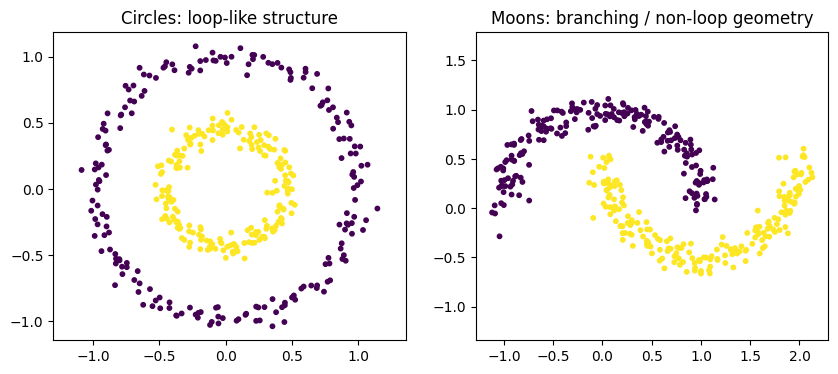

In [3]:

X1, y1 = make_circles(n_samples=400, factor=0.45, noise=0.05, random_state=42)
X2, y2 = make_moons(n_samples=400, noise=0.08, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X1[:, 0], X1[:, 1], c=y1, s=10)
axes[0].set_title("Circles: loop-like structure")
axes[0].axis("equal")

axes[1].scatter(X2[:, 0], X2[:, 1], c=y2, s=10)
axes[1].set_title("Moons: branching / non-loop geometry")
axes[1].axis("equal")
plt.show()

## 4. Lightweight topological summary without special libraries

A real TDA workflow would compute persistence diagrams.  
To keep this notebook runnable everywhere, we first build a simple **proxy feature**:

- estimate radial distance from the center
- summarize how strongly the cloud concentrates around a ring

This is not persistent homology, but it gives intuition for **shape-derived features**.

In [4]:

def ring_strength(points):
    center = points.mean(axis=0)
    radii = np.linalg.norm(points - center, axis=1)
    return radii.mean() / (radii.std() + 1e-8)

circle_strength = ring_strength(X1)
moon_strength = ring_strength(X2)

print("Ring-strength proxy")
print(f"Circles dataset: {circle_strength:.3f}")
print(f"Moons dataset:   {moon_strength:.3f}")

Ring-strength proxy
Circles dataset: 2.617
Moons dataset:   2.401


A stronger ring-like concentration often indicates a more stable loop structure.  
Persistent homology is more principled because it tracks features **across scales** rather than using a single handcrafted descriptor.

## 5. Images and digit intuition

The lecture notes the classic intuition:
- **0** tends to have one loop
- **8** tends to have two loops
- **1** often has no loop

Topology alone is usually not enough for classification, but it can complement pixel features or CNN embeddings.

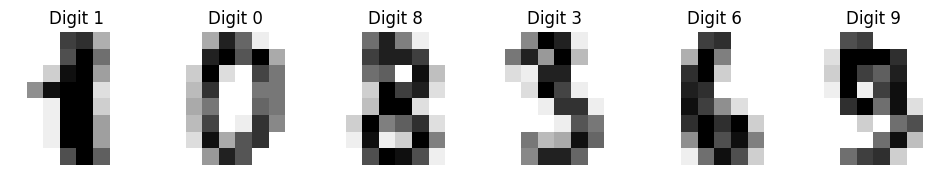

In [5]:

digits = load_digits()
X = digits.data
y = digits.target
images = digits.images

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
chosen = [1, 0, 8, 3, 6, 9]
for ax, d in zip(axes, chosen):
    idx = np.where(y == d)[0][0]
    ax.imshow(images[idx], cmap='gray_r')
    ax.set_title(f"Digit {d}")
    ax.axis('off')
plt.show()

### Hybrid idea: pixels plus structural summary

Below we construct a very simple handcrafted summary from each image:
- number of pixels above a threshold
- rough estimate of holes by looking at dark center vs bright ring behavior

This is only a toy approximation, but it mirrors the lecture’s message:  
**combine topology-inspired summaries with conventional features**.

In [6]:

def simple_image_features(img):
    img = np.array(img)
    active = (img > 6).astype(int)
    mass = active.sum()

    # very rough loop cue:
    center = active[2:6, 2:6].sum()
    border = active.sum() - center
    loop_hint = border - center
    return np.array([mass, center, border, loop_hint], dtype=float)

toy_feats = np.vstack([simple_image_features(img) for img in images])
toy_feats[:5]

array([[23.,  8., 15.,  7.],
       [20.,  9., 11.,  2.],
       [24., 11., 13.,  2.],
       [21.,  7., 14.,  7.],
       [18., 11.,  7., -4.]])

In [7]:

X_train, X_test, y_train, y_test = train_test_split(toy_feats, y, test_size=0.3, random_state=42)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(classification_report(y_test, pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.21      0.25      0.23        53
           1       0.15      0.14      0.14        50
           2       0.26      0.34      0.30        47
           3       0.28      0.30      0.29        54
           4       0.53      0.65      0.59        60
           5       0.19      0.14      0.16        66
           6       0.12      0.06      0.08        53
           7       0.12      0.07      0.09        55
           8       0.25      0.49      0.33        43
           9       0.19      0.15      0.17        59

    accuracy                           0.25       540
   macro avg       0.23      0.26      0.24       540
weighted avg       0.23      0.25      0.24       540



The performance is limited because the features are tiny and crude.  
That is actually the point: **structure helps, but topology should usually be paired with richer representations**.

## 6. Time series and sliding-window embeddings

The lecture highlights that periodic signals often become loop-like after an embedding step.  
A simple delay embedding of a periodic signal often traces out a closed curve.

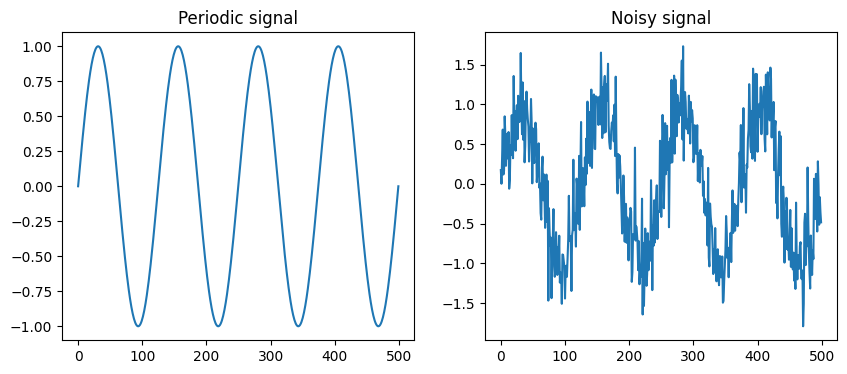

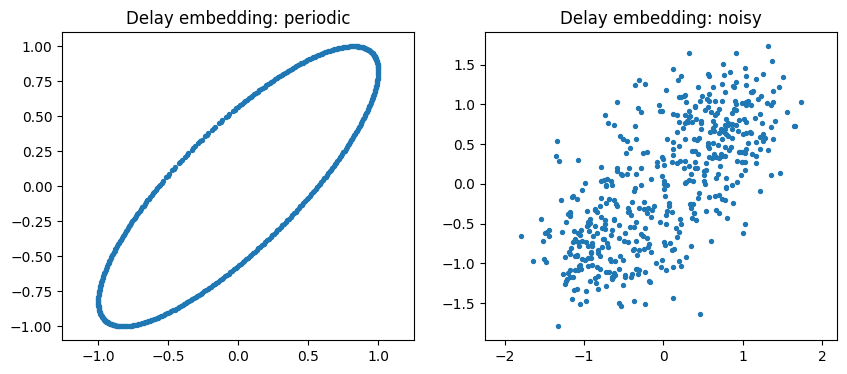

In [8]:

t = np.linspace(0, 8 * np.pi, 500)
signal_periodic = np.sin(t)
signal_noisy = np.sin(t) + 0.35 * np.random.randn(len(t))

def delay_embed(signal, delay=10, dim=2):
    n = len(signal) - delay * (dim - 1)
    emb = np.column_stack([signal[i:i+n] for i in range(0, delay * dim, delay)])
    return emb

emb_periodic = delay_embed(signal_periodic, delay=12, dim=2)
emb_noisy = delay_embed(signal_noisy, delay=12, dim=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(signal_periodic)
axes[0].set_title("Periodic signal")

axes[1].plot(signal_noisy)
axes[1].set_title("Noisy signal")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(emb_periodic[:, 0], emb_periodic[:, 1], s=8)
axes[0].set_title("Delay embedding: periodic")
axes[0].axis("equal")

axes[1].scatter(emb_noisy[:, 0], emb_noisy[:, 1], s=8)
axes[1].set_title("Delay embedding: noisy")
axes[1].axis("equal")
plt.show()

For a strongly periodic signal, the delay embedding often suggests **one dominant loop**.  
This is exactly the kind of geometric pattern that persistent homology can capture more formally.

## 7. Sensor-network intuition: coverage holes

In the lecture, a loop in an appropriate complex can indicate a **coverage gap**.  
The plot below shows sensors as points with coverage disks. A central hole is easy to spot visually.

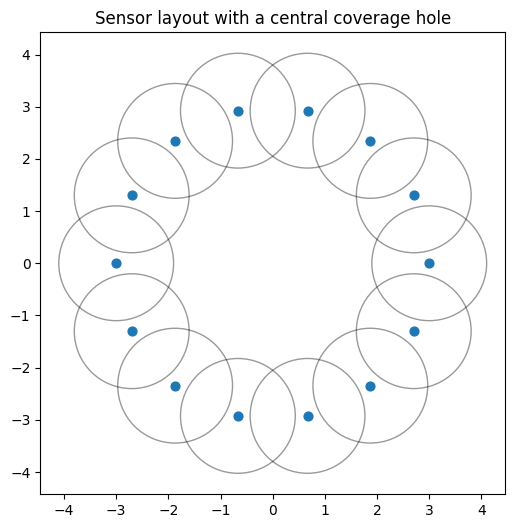

In [9]:

angles = np.linspace(0, 2 * np.pi, 14, endpoint=False)
radius = 3.0
sensors = np.c_[radius * np.cos(angles), radius * np.sin(angles)]
coverage_r = 1.1

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sensors[:, 0], sensors[:, 1], s=40)

for x, y in sensors:
    circ = plt.Circle((x, y), coverage_r, fill=False, alpha=0.4)
    ax.add_patch(circ)

ax.set_title("Sensor layout with a central coverage hole")
ax.axis("equal")
plt.show()

This picture is a clean example of a topological object with operational meaning:
a loop can correspond to a **hole in coverage**, not just an abstract mathematical feature.

## 8. Materials and porous structure

For materials science, the lecture stresses:
- pores
- tunnels
- cavities
- connectivity across scales

These are naturally topological concepts.  
Below is a synthetic porous image where holes and channels matter more than individual pixel values.

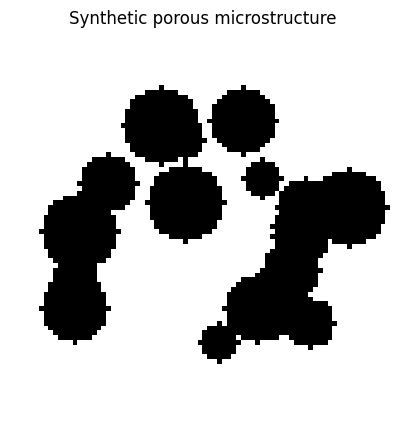

In [10]:

grid = np.zeros((80, 80))
rng = np.random.default_rng(42)

for _ in range(18):
    cx, cy = rng.integers(8, 72, size=2)
    r = rng.integers(4, 9)
    yy, xx = np.ogrid[:80, :80]
    mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    grid[mask] = 1

plt.figure(figsize=(5, 5))
plt.imshow(grid, cmap='gray_r')
plt.title("Synthetic porous microstructure")
plt.axis("off")
plt.show()

## 9. Mapper intuition

The lecture distinguishes **Mapper** from persistent homology:
- persistent homology tracks features across scale
- Mapper gives a lens-based graph summary for exploration

Below is a small sketch of a Mapper-like workflow using PCA as a lens and overlapping bins.

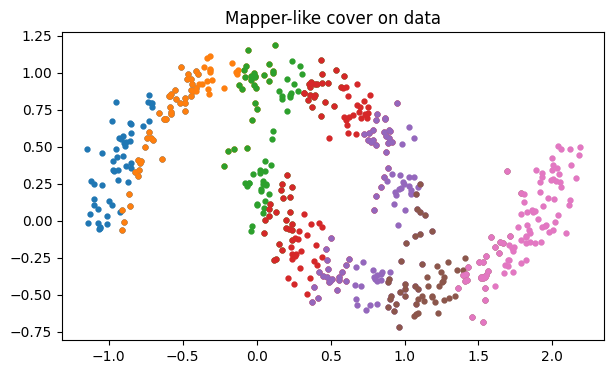

Number of overlapping bins / local groups: 7


In [11]:

X_map, y_map = make_moons(n_samples=500, noise=0.1, random_state=7)
lens = PCA(n_components=1).fit_transform(X_map).ravel()

bins = np.linspace(lens.min(), lens.max(), 8)
overlap = 0.25 * (bins[1] - bins[0])

clusters = []
for i in range(len(bins) - 1):
    left = bins[i] - overlap
    right = bins[i + 1] + overlap
    idx = np.where((lens >= left) & (lens <= right))[0]
    if len(idx) > 0:
        clusters.append(idx)

plt.figure(figsize=(7, 4))
plt.scatter(X_map[:, 0], X_map[:, 1], c='lightgray', s=10)
for idx in clusters:
    plt.scatter(X_map[idx, 0], X_map[idx, 1], s=12)
plt.title("Mapper-like cover on data")
plt.axis("equal")
plt.show()

print(f"Number of overlapping bins / local groups: {len(clusters)}")

This is only an intuition-building sketch, not a full Mapper implementation.  
But it matches the lecture’s point: Mapper is useful for **visualizing heterogeneity, branches, and transitional samples**.

## 10. If a TDA library is available

The next cell tries to use `ripser` to compute a real persistence diagram for a circle and a noisy cloud.
If `ripser` is not installed, the notebook will skip gracefully.

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.3 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=920f06de00e70d620efd51536b1877dae4cdbe30648bb5fdca05edff01f04e6e
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


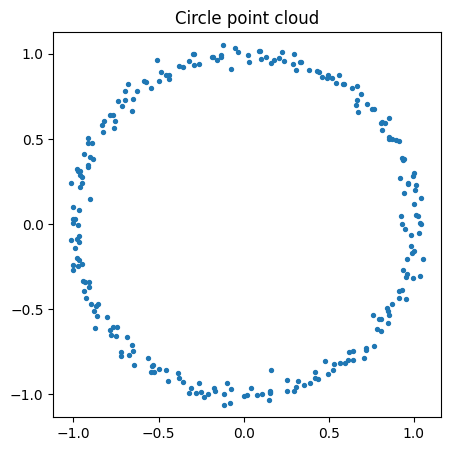

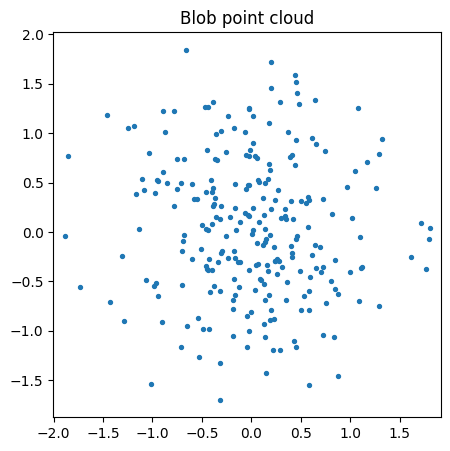

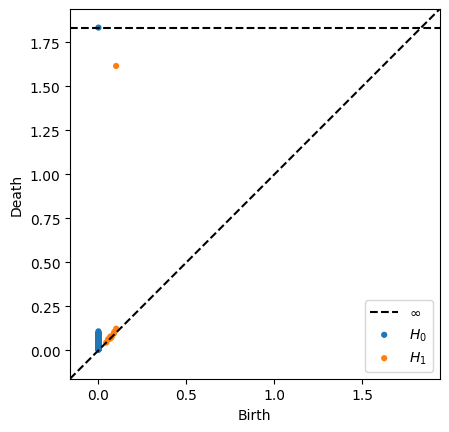

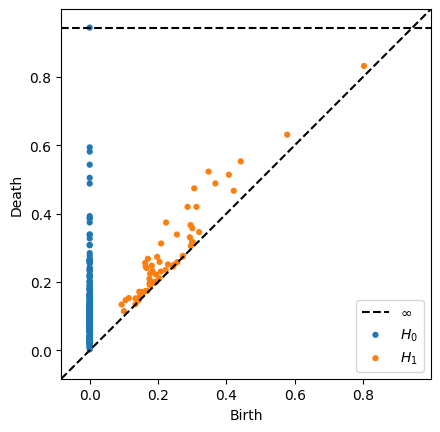

In [12]:
!pip install Cython
!pip install Ripser
try:
    from ripser import ripser
    from persim import plot_diagrams

    X_circle, _ = make_circles(n_samples=250, factor=0.999, noise=0.03, random_state=1)
    X_blob = np.random.randn(250, 2) * 0.7

    dgms_circle = ripser(X_circle, maxdim=1)['dgms']
    dgms_blob = ripser(X_blob, maxdim=1)['dgms']

    plt.figure(figsize=(5, 5))
    plt.scatter(X_circle[:, 0], X_circle[:, 1], s=8)
    plt.title("Circle point cloud")
    plt.axis("equal")
    plt.show()

    plt.figure(figsize=(5, 5))
    plt.scatter(X_blob[:, 0], X_blob[:, 1], s=8)
    plt.title("Blob point cloud")
    plt.axis("equal")
    plt.show()

    plot_diagrams(dgms_circle, show=True)
    plot_diagrams(dgms_blob, show=True)

except Exception as e:
    print("ripser/persim not available in this environment.")
    print("Reason:", e)

When available, this is the step where the lecture’s full story becomes concrete:

**persistence diagram → vectorized feature → downstream model**

## 11. Common vectorizations

The lecture lists several common ways to turn persistence into ML-ready features:
- persistence landscapes
- persistence images
- summary statistics of bars
- kernel methods on diagrams

Below is a tiny mock example showing how summary statistics might look.

In [13]:

mock_birth = np.array([0.1, 0.2, 0.15, 0.05])
mock_death = np.array([0.9, 0.35, 0.25, 0.08])
lifetimes = mock_death - mock_birth

summary = {
    "num_features": len(lifetimes),
    "max_persistence": lifetimes.max(),
    "mean_persistence": lifetimes.mean(),
    "sum_persistence": lifetimes.sum(),
}
summary

{'num_features': 4,
 'max_persistence': np.float64(0.8),
 'mean_persistence': np.float64(0.27),
 'sum_persistence': np.float64(1.08)}

## 12. Advantages and limitations

From the lecture:

### Advantages
- captures global structure
- often robust to noise
- works in high-dimensional settings
- complements classical ML features

### Limitations
- computational cost can grow quickly
- results depend on representation, metric, and filtration
- interpretation is domain dependent
- topology alone may not be predictive enough

## 13. Reflection questions

1. Why is persistent homology often an intermediate object rather than the final output?  
2. Why can topology be useful for time series only **after** embedding?  
3. In what sense is Mapper different from persistent homology?  
4. Why should TDA usually be combined with domain features?

## 14. Suggested software tools

The lecture mentions:
- **Ripser** — fast persistent homology
- **GUDHI** — broad TDA toolkit
- **Dionysus** — research-oriented library
- **giotto-tda** — sklearn-style pipeline tools

## 15. Takeaway

The main lesson of Lecture 3 is:

> TDA becomes powerful in applications when topological summaries are combined with task-specific representations and domain knowledge.

Topology is a structural lens — not a miracle feature.